# <span style="color:#1E2D6B">PA-BI E-Commerce</span>  
## <span style="color:#E669B9">Machine Learning</span>

---

### <span style="color:#1E2D6B">Introduction</span>
Welcome to the <span style="color:#E669B9">Machine Learning</span> section.

---

### <span style="color:#1E2D6B">Applications</span>
- <span style="color:#E669B9">Product Recommendation</span>  
- <span style="color:#E669B9">Customer Segmentation</span>  

## <span style="color:#E669B9">Regression Task</span>

---

### <span style="color:#1E2D6B">Objective</span>
The main objective of this part is to build a regression model  
that predicts the **monetary value of the next order** placed by a customer:

- <span style="color:#E669B9">Target variable</span> : `Montant_de_la_commande` (order amount in TND)  
- <span style="color:#E669B9">Granularity</span> : One row per transaction  
- <span style="color:#E669B9">Type</span> : Supervised regression (continuous numerical output)  

---

### <span style="color:#1E2D6B">Approach</span>
We will use machine learning regression techniques to analyze transaction data  
and identify patterns that influence the order amount.

The models will be trained on features extracted from the Data Warehouse:

- <span style="color:#E669B9">Transaction features</span> : quantity, unit price, discount, delivery cost, promo code  
- <span style="color:#E669B9">Product features</span> : catalogue price, promotion status, product category  
- <span style="color:#E669B9">Client features</span> : client type (B2B / B2C), city, sales channel  
- <span style="color:#E669B9">Temporal features</span> : month, quarter, semester, high season indicator  

---

### <span style="color:#1E2D6B">Models Used</span>
At least two models will be implemented and compared:

- <span style="color:#E669B9">Random Forest Regressor</span> — robust non-linear ensemble model  
- <span style="color:#E669B9">Ridge Regression</span>

---

### <span style="color:#1E2D6B">Evaluation Metrics</span>
Models will be compared using the following metrics:

- <span style="color:#E669B9">MAE</span> — Mean Absolute Error (average error in TND, easy to interpret)  
- <span style="color:#E669B9">RMSE</span> — Root Mean Squared Error (penalizes large errors)  
- <span style="color:#E669B9">R²</span> — Coefficient of determination (% of variance explained by the model)  

---

### <span style="color:#1E2D6B">Expected Outcome</span>
A predictive model capable of helping the business:

- Anticipate revenue and improve financial planning  
- Personalize commercial offers based on predicted order value  
- Identify high-value transactions and prioritize B2B relationships  
- Optimize pricing and discount strategies for artisanal products

# Dependencies Instalation

In [2]:
pip install pyodbc sqlalchemy pandas

# Datawarehouse Connexion

In [3]:
import pyodbc
import pandas as pd
from sqlalchemy import create_engine, text
import urllib
import numpy as np

# ── Paramètres de connexion ───────────────────────────────────
SERVER   = "KALLALA" 
DATABASE = "DW_E-Commerce"      

# ── Chaîne de connexion ───────────────────────────────────────
connection_string = (
    f"DRIVER={{ODBC Driver 17 for SQL Server}};"
    f"SERVER={SERVER};"
    f"DATABASE={DATABASE};"
    f"Trusted_Connection=yes;"
)

params = urllib.parse.quote_plus(connection_string)
engine = create_engine(f"mssql+pyodbc:///?odbc_connect={params}")

try:
    with engine.connect() as conn:
        print("Connexion réussie !")
        result = conn.execute(text("SELECT DB_NAME() AS base_active"))  
        print("Base active :", result.fetchone()[0])
except Exception as e:
    print("Erreur de connexion :", e)

Connexion réussie !
Base active : DW_E-Commerce


# Tables Verification

In [4]:
df_tables = pd.read_sql(text("""
    SELECT TABLE_NAME
    FROM INFORMATION_SCHEMA.TABLES
    WHERE TABLE_TYPE = 'BASE TABLE'
    ORDER BY TABLE_NAME
"""), engine)

print("── Tables disponibles ──")
print(df_tables.to_string(index=False))

# ── Nombre de lignes par table ────────────────────────────────
tables = ['Fact_Ventes', 'Fact_Achats', 'Dim_Client',
          'Dim_Produit', 'DimDates', 'Dim_Geographie',
          'Dim_Type_Vente', 'Dim_Mode_Paiement',
          'Dim_Categorie', 'Dim_Fournisseur']

print("\n── Nombre de lignes par table ──")
for t in tables:
    try:
        n = pd.read_sql(text(f"SELECT COUNT(*) AS n FROM {t}"),
                        engine)['n'][0]
        print(f"  {t:30s} → {n:>8,} lignes")
    except:
        print(f"  {t:30s} → introuvable")

── Tables disponibles ──
              TABLE_NAME
  Dictionnaire_Categorie
 Dictionnaire_Geographie
           Dim_Categorie
              Dim_Client
         Dim_Fournisseur
          Dim_Geographie
       Dim_Mode_Paiement
             Dim_Produit
Dim_Produits_Concurrents
          Dim_Type_Vente
                DimDates
             Fact_Achats
             Fact_Ventes
             sysdiagrams
           Ville_Tunisie

── Nombre de lignes par table ──
  Fact_Ventes                    →      831 lignes
  Fact_Achats                    →      270 lignes
  Dim_Client                     →      464 lignes
  Dim_Produit                    →      741 lignes
  DimDates                       →   36,891 lignes
  Dim_Geographie                 →       21 lignes
  Dim_Type_Vente                 →        2 lignes
  Dim_Mode_Paiement              →        9 lignes
  Dim_Categorie                  →       37 lignes
  Dim_Fournisseur                →       78 lignes


In [5]:
import sys
!{sys.executable} -m pip install --upgrade scikit-learn

In [6]:
import sklearn
print(sklearn.__version__)

1.8.0


# Fact table overview

In [7]:
# ── Aperçu Fact_Ventes ────────────────────────────────────────
print("── Structure Fact_Ventes ──")
df_struct = pd.read_sql(text("""
    SELECT COLUMN_NAME, DATA_TYPE
    FROM INFORMATION_SCHEMA.COLUMNS
    WHERE TABLE_NAME = 'Fact_Ventes'
    ORDER BY ORDINAL_POSITION
"""), engine)
print(df_struct.to_string(index=False))

# ── Statistiques descriptives des colonnes numériques ─────────
print("\n── Statistiques Fact_Ventes ──")
df_fact = pd.read_sql(text("""
    SELECT
        COUNT(*)                          AS nb_lignes,
        COUNT(DISTINCT Client_FK)         AS nb_clients,
        COUNT(DISTINCT Produit_FK)        AS nb_produits,
        COUNT(DISTINCT Numero_Facture)    AS nb_factures,
        COUNT(DISTINCT Numero_Commande)   AS nb_commandes_web,

        -- Cible : Montant_de_la_commande
        MIN(Montant_de_la_commande)       AS montant_min,
        MAX(Montant_de_la_commande)       AS montant_max,
        AVG(Montant_de_la_commande)       AS montant_moyen,

        -- Autres montants
        AVG(Montant_Remise)               AS remise_moyenne,
        AVG(Montant_Livraison)            AS livraison_moyenne,
        AVG(Prix_Unité)                   AS prix_unite_moyen,

        -- Quantité
        MIN(Quantite)                     AS qte_min,
        MAX(Quantite)                     AS qte_max,
        AVG(Quantite)                     AS qte_moyenne

    FROM Fact_Ventes
    WHERE Montant_de_la_commande > 0
"""), engine)
print(df_fact.T.to_string(header=False))

# ── Distribution de la cible ──────────────────────────────────
print("\n── Distribution Montant_de_la_commande ──")
df_dist = pd.read_sql(text("""
    SELECT
        PERCENTILE_CONT(0.25) WITHIN GROUP
            (ORDER BY Montant_de_la_commande) OVER () AS Q1,
        PERCENTILE_CONT(0.50) WITHIN GROUP
            (ORDER BY Montant_de_la_commande) OVER () AS mediane,
        PERCENTILE_CONT(0.75) WITHIN GROUP
            (ORDER BY Montant_de_la_commande) OVER () AS Q3,
        PERCENTILE_CONT(0.90) WITHIN GROUP
            (ORDER BY Montant_de_la_commande) OVER () AS P90,
        PERCENTILE_CONT(0.99) WITHIN GROUP
            (ORDER BY Montant_de_la_commande) OVER () AS P99
    FROM Fact_Ventes
    WHERE Montant_de_la_commande > 0
"""), engine)
print(df_dist.drop_duplicates().T.to_string(header=False))

── Structure Fact_Ventes ──
           COLUMN_NAME DATA_TYPE
              Vente_PK       int
               Date_FK       int
         Type_Vente_FK       int
            Produit_FK       int
          Categorie_FK       int
             Client_FK       int
         Geographie_FK       int
      Mode_Paiement_FK       int
              Quantite       int
     Montant_Livraison     float
 Montant_Remboursement     float
Montant_de_la_commande     float
        Montant_Remise     float
            Code_Promo  nvarchar
        Numero_Facture  nvarchar
       Numero_Commande  nvarchar
            Prix_Unité     float

── Statistiques Fact_Ventes ──
nb_lignes            823.000000
nb_clients           438.000000
nb_produits          209.000000
nb_factures           45.000000
nb_commandes_web     433.000000
montant_min            1.000000
montant_max        56525.000000
montant_moyen        511.672928
remise_moyenne         0.440462
livraison_moyenne      6.509113
prix_unite_moyen      54.9

# Dataframe Description :


## <span style="color:#E669B9">Target Variable</span>

| Column                     | Type        | Description |
|---------------------------|------------|------------|
| Montant_de_la_commande   | float      | Target variable. Represents the total value of a customer order in TND. |

---

## <span style="color:#E669B9">Transaction Features</span>

| Column                  | Type   | Description |
|------------------------|--------|------------|
| Quantite              | int    | Number of items purchased in the order |
| Prix_Unité            | float  | Unit price of the product |
| Montant_Remise        | float  | Discount amount applied on the order |
| Montant_Livraison     | float  | Delivery cost of the order |
| a_code_promo          | int    | 1 if a promo code was used, 0 otherwise |

---

## <span style="color:#E669B9">Client Profile Features</span>

| Column        | Type     | Description |
|--------------|----------|------------|
| Type_client  | varchar  | Client type — B2B (business) or B2C (consumer) |
| ville_client | varchar  | City of the client |

---

## <span style="color:#E669B9">Product Features</span>

| Column         | Type    | Description |
|----------------|--------|------------|
| prix_catalogue | float  | Base catalog price of the product |
| En_Promo       | int    | Indicates if product is on promotion |
| canal_produit  | varchar| Product sales channel |

---

## <span style="color:#E669B9">Category Feature</span>

| Column      | Type   | Description |
|------------|--------|------------|
| Categorie  | varchar| Product category (e.g. pottery, embroidery, leather) |

---

## <span style="color:#E669B9">Sales & Payment Features</span>

| Column         | Type   | Description |
|---------------|--------|------------|
| Type_Vente    | varchar| Type of sale (B2B, B2C, etc.) |
| Type_paiement | varchar| Payment method used |

---

## <span style="color:#E669B9">Date Features</span>

| Column              | Type | Description |
|---------------------|------|------------|
| Annee              | int  | Year of the transaction |
| Mois               | int  | Month of the transaction |
| Trimestre          | int  | Quarter of the year |
| Semestre           | int  | Semester of the year |
| est_saison_haute   | int  | 1 if month is in high season (Jun, Jul, Aug, Dec), else 0 |

---

## <span style="color:#E669B9">Columns Excluded Before Training</span>

| Column | Reason |
|--------|--------|
| Vente_PK | Technical identifier — no predictive value |

---

## <span style="color:#E669B9">Final Dataset Shape</span>

| Element            | Value |
|--------------------|------|
| Granularity        | 1 row per transaction |
| Source tables      | Fact_Ventes, Dim_Client, Dim_Produit, Dim_Categorie, Dim_Type_Vente, Dim_Mode_Paiement, DimDates |
| Target             | Montant_de_la_commande (continuous) |
| Encoding needed    | Type_client, ville_client, canal_vente, canal_produit, Categorie, Type_Vente, Type_paiement |
| Scaling needed     | All numeric features (StandardScaler recommended) |
| Objective          | Predict order value (regression problem) |

---

# DataFrame Construction

In [8]:
query_regression_b2c = text("""
SELECT
    fv.Numero_Commande,   

    --  Cible (une seule valeur par commande)
    MAX(fv.Montant_de_la_commande) AS Montant_de_la_commande,

    --  Features agrégées
    SUM(fv.Quantite)           AS Quantite_totale,
    AVG(fv.Prix_Unité)         AS Prix_Unité_moyen,
    SUM(fv.Montant_Remise)     AS Montant_Remise,
    SUM(fv.Montant_Livraison)  AS Montant_Livraison,

    MAX(CASE WHEN fv.Code_Promo IS NOT NULL
         AND fv.Code_Promo != ''
         AND fv.Code_Promo != 'Aucun'
         THEN 1 ELSE 0 END) AS a_code_promo,

    --  Dimensions
    MAX(dc.Type_client)       AS Type_client,
    MAX(dc.Ville)             AS ville_client,
    MAX(dp.Prix)              AS prix_catalogue,
    CASE 
    WHEN MAX(CAST(dp.En_Promo AS INT)) = 1 THEN 1 
    ELSE 0 
END AS En_Promo,
    MAX(dp.Canal)             AS canal_produit,
    MAX(dcat.Categorie)       AS categorie,
    MAX(dtv.Type_Vente)       AS type_vente,
    MAX(dmp.Type_paiement)    AS type_paiement,

    --  Temps
    MAX(dd.Annee)             AS Annee,
    MAX(dd.Mois)              AS Mois,
    MAX(dd.Trimestre)         AS Trimestre,
    MAX(dd.Semestre)          AS Semestre,

    MAX(CASE WHEN dd.Mois IN (6,7,8,12)
         THEN 1 ELSE 0 END) AS est_saison_haute

FROM Fact_Ventes fv
JOIN Dim_Client dc   ON fv.Client_FK = dc.Client_PK
JOIN Dim_Produit dp  ON fv.Produit_FK = dp.Produit_PK
JOIN Dim_Categorie dcat ON fv.Categorie_FK = dcat.Categorie_PK
JOIN Dim_Type_Vente dtv ON fv.Type_Vente_FK = dtv.Type_Vente_PK
JOIN Dim_Mode_Paiement dmp ON fv.Mode_Paiement_FK = dmp.Mode_Paiement_PK
JOIN DimDates dd ON fv.Date_FK = dd.Date_PK

WHERE fv.Montant_de_la_commande > 0
AND dd.Date != '1111-11-11'
AND fv.Numero_Facture = 'Aucun'   -- Khater B2C kahaw

GROUP BY fv.Numero_Commande
ORDER BY MAX(dd.Date)
""")

# ── Chargement ───────────────────────────────────────────────
df_reg = pd.read_sql(query_regression_b2c, engine)

print(f"Dataframe Shape : {df_reg.shape}")

print(f"\nVerification :")
print(f"  orders number: {df_reg['Numero_Commande'].nunique():,}")
print(f"  Total lines     : {len(df_reg):,}")

# ── Key Verification ───────────────────────────────────────

duplicates = df_reg['Numero_Commande'].duplicated().sum()
print(f"\nDoublons Numero_Commande : {duplicates}")

# ── Target Statistics ───────────────────────────────────────
col_target = 'Montant_de_la_commande'

if col_target in df_reg.columns:
    print(f"\nTarget Statistics :")
    print(df_reg[col_target].describe().round(2))
else:
    raise ValueError(f"Colonne {col_target} introuvable")

# ── Feature Engineering  ─────────────────────────────

if 'Montant_Remise' in df_reg.columns and 'prix_catalogue' in df_reg.columns:
    df_reg['remise_pct'] = (
        df_reg['Montant_Remise'] /
        df_reg['prix_catalogue'].replace(0, np.nan)
    ).fillna(0).clip(0, 1)
else:
    print("⚠️ remise_pct non calculée (colonnes manquantes)")

if 'Prix_Unité_moyen' in df_reg.columns and 'prix_catalogue' in df_reg.columns:
    df_reg['ratio_prix_catalogue'] = (
        df_reg['Prix_Unité_moyen'] /
        df_reg['prix_catalogue'].replace(0, np.nan)
    ).fillna(1).clip(0, 2)
else:
    print("⚠️ ratio_prix_catalogue not calculated")

# ── Data Verification ────────────────────────────────────
if 'Type_client' in df_reg.columns:
    print(f"\nType_client unique : {df_reg['Type_client'].unique()}")

print(f"\nMissing Values :")
missing = df_reg.isnull().sum()
print(missing[missing > 0])

# ──  final summary ─────────────────────────────────────────────
print(f"\n Final B2C DataFrame  :")
print(f"  Rows   : {df_reg.shape[0]:,}")
print(f"  Columns : {df_reg.shape[1]}")


Dataframe Shape : (432, 20)

Verification :
  orders number: 432
  Total lines     : 432

Doublons Numero_Commande : 0

Target Statistics :
count     432.00
mean       95.11
std       506.25
min         1.00
25%        15.97
50%        50.00
75%        97.90
max      7600.00
Name: Montant_de_la_commande, dtype: float64

Type_client unique : ['Particulier']

Missing Values :
ville_client    1
dtype: int64

 Final B2C DataFrame  :
  Rows   : 432
  Columns : 22


In [9]:
# ── Outliers Treatement (IQR) ─────────────────────────────

col = 'Montant_de_la_commande'

Q1 = df_reg[col].quantile(0.25)
Q3 = df_reg[col].quantile(0.75)
IQR = Q3 - Q1

# Bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Lower bound : {lower_bound}")
print(f"Upper bound : {upper_bound}")

# Filtering
df_reg= df_reg[
    (df_reg[col] >= lower_bound) & 
    (df_reg[col] <= upper_bound)
]

# Verification
print("\nBefore treatement :", df_reg.shape)
print("After treatement :", df_reg.shape)
print("Count of Deleted lines :", df_reg.shape[0] - df_reg.shape[0])

Lower bound : -106.93125
Upper bound : 220.79875

Before treatement : (422, 22)
After treatement : (422, 22)
Count of Deleted lines : 0


In [10]:
import sklearn, sys
print(sklearn.__version__)   # doit être 1.8.0
print(sys.executable)        # doit pointer vers anaconda3

1.8.0
c:\Users\mehdi\anaconda3\python.exe


# Target Distribution 

═════════════════════════════════════════════
 Target DIAGNOSTIC 
═════════════════════════════════════════════
count    422.000000
mean      54.054787
std       40.671710
min        1.000000
25%       14.547500
50%       45.500000
75%       94.000000
max      187.000000
Name: Montant_de_la_commande, dtype: float64

Skewness : 0.48149791529417285
Kurtosis : -0.6693909532886613


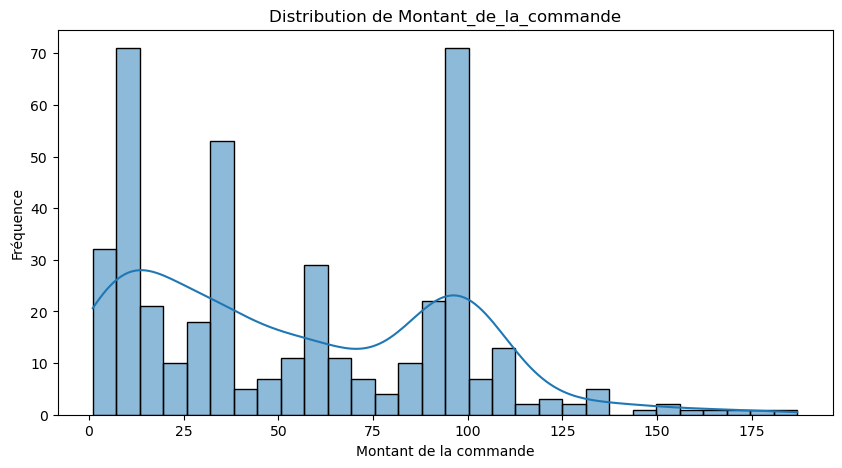

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

print("═" * 45)
print(" Target DIAGNOSTIC ")
print("═" * 45)

target = df_reg['Montant_de_la_commande']

print(target.describe())

print("\nSkewness :", target.skew())
print("Kurtosis :", target.kurt())

# ── Distribution plot ───────────────────────────────────────
plt.figure(figsize=(10, 5))

sns.histplot(target, bins=30, kde=True)

plt.title("Distribution de Montant_de_la_commande")
plt.xlabel("Montant de la commande")
plt.ylabel("Fréquence")

plt.show()

# Visualisation 

📊 Intervalles de prix :
Basse   : [1.00 → 27.00] TND
Moyenne : [27.00 → 82.60] TND
Chère   : [82.60 → 187.00] TND


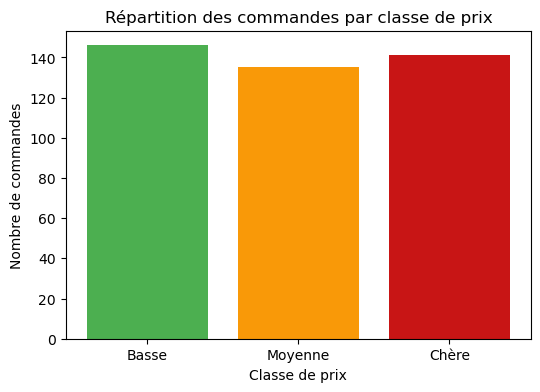

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

# ── Création des 3 classes de prix ─────────────────────────
df_reg['classe_prix'] = pd.qcut(
    df_reg['Montant_de_la_commande'],
    q=3,
    labels=['Basse', 'Moyenne', 'Chère']
)

# ── Récupération des bornes (intervalles) ──────────────────
bins = pd.qcut(df_reg['Montant_de_la_commande'], q=3, retbins=True)[1]

print("📊 Intervalles de prix :")
print(f"Basse   : [{bins[0]:.2f} → {bins[1]:.2f}] TND")
print(f"Moyenne : [{bins[1]:.2f} → {bins[2]:.2f}] TND")
print(f"Chère   : [{bins[2]:.2f} → {bins[3]:.2f}] TND")

# ── Comptage des classes ───────────────────────────────────
counts = df_reg['classe_prix'].value_counts().sort_index()

# ── Couleurs ───────────────────────────────────────────────
colors = ['#4CAF50', "#F99908", "#C81515"]

# ── Visualisation ───────────────────────────────────────────
plt.figure(figsize=(6,4))
plt.bar(counts.index, counts.values, color=colors)

plt.title("Répartition des commandes par classe de prix")
plt.xlabel("Classe de prix")
plt.ylabel("Nombre de commandes")

plt.show()


📊 Intervalles de prix :


<span style="color:#4CAF50">  Basse   : [18.00 → 85.00] TND </span>


<span style="color:#F99908">  Moyenne : [85.00 → 100.00] TND </span>


<span style="color:#C81515">  Chère   : [100.00 → 156.00] TND</span>

# Random Forest Regressor

In [13]:
# Target
y = df_reg['Montant_de_la_commande']

# Features
X = df_reg.drop(columns=['Montant_de_la_commande'])

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [15]:
print("X_train shape : "+str(X_train.shape)+" | X_test shape : "+str(X_test.shape))
print("y_train shape : "+str(y_train.shape)+" | y_test shape : "+str(y_test.shape))

X_train shape : (337, 22) | X_test shape : (85, 22)
y_train shape : (337,) | y_test shape : (85,)


In [16]:
from sklearn.model_selection import GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor

# ── Colonnes ─────────────────────────────────────────
num_cols = X.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X.select_dtypes(include=['object']).columns

# ── Preprocessing ────────────────────────────────────
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
])

# ── Pipeline ──────────────────────────────────────────
pipe = Pipeline([
    ('prep', preprocessor),
    ('model', RandomForestRegressor(random_state=42))
])

# ── Paramètres GridSearch ────────────────────────────
params = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [None, 10, 20],
    'model__min_samples_split': [2, 5]
}

# ── GridSearch ───────────────────────────────────────
grid = GridSearchCV(
    pipe,
    params,
    cv=5,
    scoring='neg_mean_absolute_error',
    n_jobs=-1
)

# ── Fit ──────────────────────────────────────────────
grid.fit(X_train, y_train)

# ── Résultats ────────────────────────────────────────
print("── Random Forest Regressor ──")
print("Meilleurs paramètres :", grid.best_params_)
print("Meilleur score CV (MAE) :", -grid.best_score_)

── Random Forest Regressor ──
Meilleurs paramètres : {'model__max_depth': None, 'model__min_samples_split': 2, 'model__n_estimators': 200}
Meilleur score CV (MAE) : 18.145075579455664


In [17]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# ── Prédictions ───────────────────────────────────────────────
y_pred_rf = grid.best_estimator_.predict(X_test)

# ── Métriques ─────────────────────────────────────────────────
mae  = mean_absolute_error(y_test, y_pred_rf)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2   = r2_score(y_test, y_pred_rf)
mape = np.mean(np.abs((y_test - y_pred_rf) / y_test.replace(0, np.nan))) * 100

print("══════════════════════════════════════")
print("  Random Forest Regressor — Test Set")
print("══════════════════════════════════════")
print(f"  MAE   : {mae:.2f}  TND")
print(f"  RMSE  : {rmse:.2f} TND")
print(f"  R²    : {r2:.4f}")
print(f"  MAPE  : {mape:.2f} %")
print("══════════════════════════════════════")
print(f"\nInterprétation :")
print(f"  → En moyenne, le modèle se trompe de {mae:.0f} TND par commande")
print(f"  → Il explique {r2*100:.1f}% de la variance du montant des commandes")
print(f"  → Erreur relative moyenne : {mape:.1f}%")

══════════════════════════════════════
  Random Forest Regressor — Test Set
══════════════════════════════════════
  MAE   : 12.62  TND
  RMSE  : 25.05 TND
  R²    : 0.6087
  MAPE  : 45.66 %
══════════════════════════════════════

Interprétation :
  → En moyenne, le modèle se trompe de 13 TND par commande
  → Il explique 60.9% de la variance du montant des commandes
  → Erreur relative moyenne : 45.7%


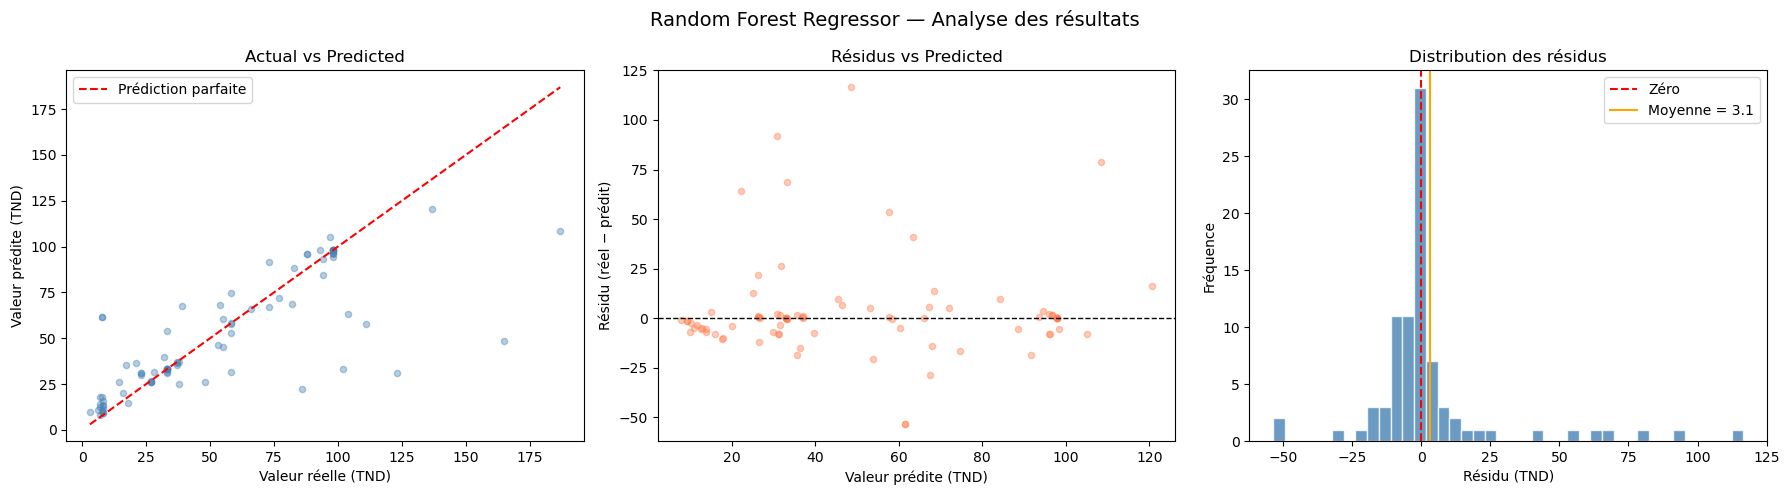

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Random Forest Regressor — Analyse des résultats", fontsize=14)

# ── 1. Actual vs Predicted ────────────────────────────────────
ax = axes[0]
ax.scatter(y_test, y_pred_rf, alpha=0.4, color='steelblue', s=20)
lims = [min(y_test.min(), y_pred_rf.min()),
        max(y_test.max(), y_pred_rf.max())]
ax.plot(lims, lims, 'r--', linewidth=1.5, label='Prédiction parfaite')
ax.set_xlabel("Valeur réelle (TND)")
ax.set_ylabel("Valeur prédite (TND)")
ax.set_title("Actual vs Predicted")
ax.legend()

# ── 2. Résidus vs Predicted ───────────────────────────────────
ax = axes[1]
residus = y_test - y_pred_rf
ax.scatter(y_pred_rf, residus, alpha=0.4, color='coral', s=20)
ax.axhline(0, color='black', linestyle='--', linewidth=1)
ax.set_xlabel("Valeur prédite (TND)")
ax.set_ylabel("Résidu (réel − prédit)")
ax.set_title("Résidus vs Predicted")

# ── 3. Distribution des résidus ───────────────────────────────
ax = axes[2]
ax.hist(residus, bins=40, color='steelblue', edgecolor='white', alpha=0.8)
ax.axvline(0,            color='red',    linestyle='--', label='Zéro')
ax.axvline(residus.mean(), color='orange', linestyle='-',
           label=f'Moyenne = {residus.mean():.1f}')
ax.set_xlabel("Résidu (TND)")
ax.set_ylabel("Fréquence")
ax.set_title("Distribution des résidus")
ax.legend()

plt.tight_layout()
plt.savefig("rf_regression_results.png", dpi=150)
plt.show()

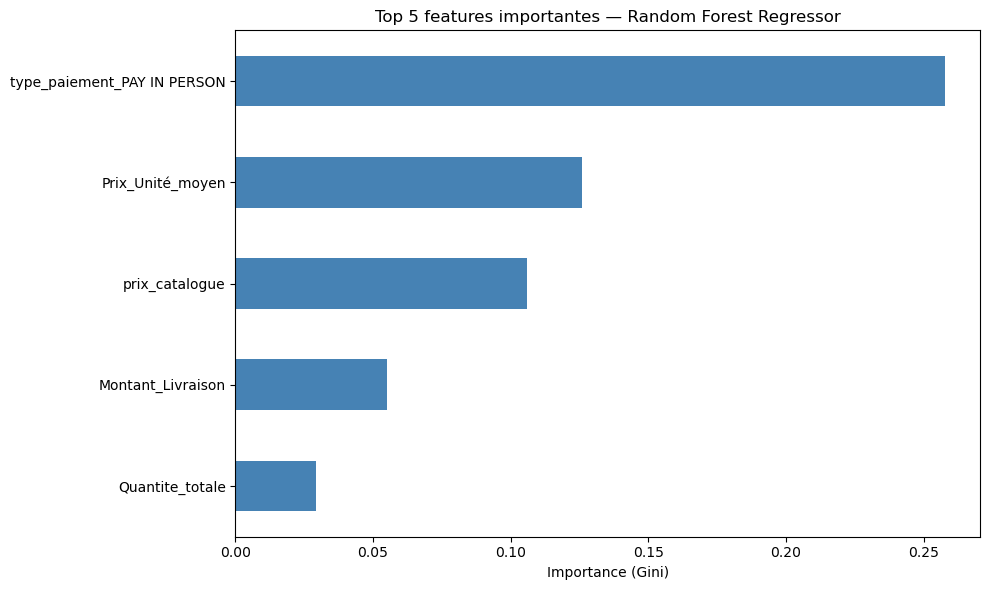


Top 5 features :
type_paiement_PAY IN PERSON    0.2576
Prix_Unité_moyen               0.1257
prix_catalogue                 0.1058
Montant_Livraison              0.0549
Quantite_totale                0.0294


In [19]:
# ── Récupérer les noms de colonnes après preprocessing ────────
rf_model = grid.best_estimator_.named_steps['model']
prep     = grid.best_estimator_.named_steps['prep']

# Noms des features après OneHotEncoding
cat_feature_names = (prep
    .named_transformers_['cat']
    .get_feature_names_out(cat_cols)
    .tolist())
all_feature_names = list(num_cols) + cat_feature_names

# ── Top 15 features ───────────────────────────────────────────
importances = pd.Series(rf_model.feature_importances_,
                        index=all_feature_names).nlargest(5)

fig, ax = plt.subplots(figsize=(10, 6))
importances.sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.set_title("Top 5 features importantes — Random Forest Regressor")
ax.set_xlabel("Importance (Gini)")
plt.tight_layout()
plt.savefig("rf_feature_importance.png", dpi=150)
plt.show()

print("\nTop 5 features :")
print(importances.head(10).round(4).to_string())

 # Ridge Regressor

In [20]:
from sklearn.linear_model import Ridge

# ── Modèle 2 : Ridge Regression (baseline linéaire) ──────────
pipe_ridge = Pipeline([
    ('prep',  preprocessor),
    ('model', Ridge())
])

params_ridge = {
    'model__alpha': [0.01, 0.1, 1, 10, 100, 1000]
}

grid_ridge = GridSearchCV(
    pipe_ridge, params_ridge,
    cv=5, scoring='neg_mean_absolute_error',
    n_jobs=-1
)
grid_ridge.fit(X_train, y_train)

y_pred_ridge = grid_ridge.best_estimator_.predict(X_test)


print("── Ridge Regressor ──")
print("Meilleurs paramètres :", grid_ridge.best_params_)

── Ridge Regressor ──
Meilleurs paramètres : {'model__alpha': 10}


# Evaluation Metrics

In [21]:
mae_r  = mean_absolute_error(y_test, y_pred_ridge)
rmse_r = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
r2_r   = r2_score(y_test, y_pred_ridge)
mape_r = np.mean(np.abs((y_test - y_pred_ridge) /
                         y_test.replace(0, np.nan))) * 100


print("══════════════════════════════════════")
print("  Ridge Regression — Test Set")
print("══════════════════════════════════════")
print(f"  MAE   : {mae_r:.2f}  TND")
print(f"  RMSE  : {rmse_r:.2f} TND")
print(f"  R²    : {r2_r:.4f}")
print(f"  MAPE  : {mape_r:.2f} %")
print("══════════════════════════════════════")

══════════════════════════════════════
  Ridge Regression — Test Set
══════════════════════════════════════
  MAE   : 23.52  TND
  RMSE  : 29.98 TND
  R²    : 0.4397
  MAPE  : 124.21 %
══════════════════════════════════════


# Comparaison des Modeles 

In [22]:
df_compare = pd.DataFrame([
    {
        'Modèle': 'Ridge Regression',
        'MAE (TND)':  round(mae_r,  2),
        'RMSE (TND)': round(rmse_r, 2),
        'R²':         round(r2_r,   4),
        'MAPE (%)':   round(mape_r, 2),
        'CV MAE':     round(-grid_ridge.best_score_, 2)
    },
    {
        'Modèle': 'Random Forest',
        'MAE (TND)':  round(mae,  2),
        'RMSE (TND)': round(rmse, 2),
        'R²':         round(r2,   4),
        'MAPE (%)':   round(mape, 2),
        'CV MAE':     round(-grid.best_score_, 2)
    }
]).sort_values('MAE (TND)')

print("\n══════════════════════════════════════════════════")
print("  Tableau comparatif — Modèles de régression")
print("══════════════════════════════════════════════════")
print(df_compare.to_string(index=False))

# Meilleur modèle
best = df_compare.iloc[0]['Modèle']
print(f"\n  Meilleur modèle : {best}")
print(f"  → MAE = {df_compare.iloc[0]['MAE (TND)']} TND")
print(f"  → R²  = {df_compare.iloc[0]['R²']}")


══════════════════════════════════════════════════
  Tableau comparatif — Modèles de régression
══════════════════════════════════════════════════
          Modèle  MAE (TND)  RMSE (TND)     R²  MAPE (%)  CV MAE
   Random Forest      12.62       25.05 0.6087     45.66   18.15
Ridge Regression      23.52       29.98 0.4397    124.21   26.12

  Meilleur modèle : Random Forest
  → MAE = 12.62 TND
  → R²  = 0.6087


In [25]:
preprocessor = model.named_steps['prep']
for name, transformer, cols in preprocessor.transformers_:
    print(f"\n--- {name} : {cols} ---")
    if hasattr(transformer, 'categories_'):
        for i, cat in enumerate(transformer.categories_):
            print(f"  col {i} : {[type(c).__name__ for c in cat[:5]]} → {cat[:5]}")


--- num : Index(['Quantite_totale', 'Prix_Unité_moyen', 'Montant_Remise',
       'Montant_Livraison', 'a_code_promo', 'prix_catalogue', 'En_Promo',
       'Annee', 'Mois', 'est_saison_haute', 'remise_pct',
       'ratio_prix_catalogue'],
      dtype='object') ---

--- cat : Index(['Numero_Commande', 'Type_client', 'ville_client', 'canal_produit',
       'categorie', 'type_vente', 'type_paiement', 'Trimestre', 'Semestre'],
      dtype='object') ---
  col 0 : ['str', 'str', 'str', 'str', 'str'] → ['11518' '11519' '11776' '11777' '11868']
  col 1 : ['str'] → ['Particulier']
  col 2 : ['str', 'str', 'str', 'str', 'str'] → ['Ariana' 'Beja' 'Ben Arous' 'Bizerte' 'Gabes']
  col 3 : ['str'] → ['Site Web']
  col 4 : ['str', 'str', 'str', 'str', 'str'] → ['ART DE LA TABLE' 'ART DE TABLE' 'ARTICLES EN CUIVRE' 'ARTISANAT'
 "BOIS D'OLIVIER"]
  col 5 : ['str'] → ['Site_Web']
  col 6 : ['str', 'str', 'str', 'str', 'str'] → ['AUTRE' 'CASH ON DELIVERY' 'PAY IN PERSON' 'PAYMEE' 'WALLET PAYMENT']
  col 

In [23]:
import joblib
joblib.dump(grid.best_estimator_,      "model_regression.pkl")
joblib.dump(list(X_train.columns),     "feature_columns_regression.pkl")

['feature_columns_regression.pkl']